# Project 1 — Gradient Boosting
## Diabetes Risk Prediction

Predicting diabetes risk (synthetic, styled after the Pima Indians Diabetes dataset) from glucose, BMI, blood pressure, age, and insulin level.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)
np.random.seed(42)
pd.set_option('display.max_columns', None)


## 1. Generate / Load Data

In [2]:
n = 800
is_diabetic = np.random.choice([0,1], n, p=[0.65,0.35])
glucose = np.where(is_diabetic==1, np.random.normal(160,30,n), np.random.normal(100,20,n)).clip(50,250)
bmi = np.where(is_diabetic==1, np.random.normal(33,6,n), np.random.normal(25,5,n)).clip(15,55)
blood_pressure = np.where(is_diabetic==1, np.random.normal(85,12,n), np.random.normal(72,10,n)).clip(40,130)
age = np.random.randint(21,80,n)
insulin = np.where(is_diabetic==1, np.random.gamma(3,50,n), np.random.gamma(2,30,n))

df = pd.DataFrame({'glucose': glucose, 'bmi': bmi, 'blood_pressure': blood_pressure,
                    'age': age, 'insulin': insulin, 'diabetic': is_diabetic})
df.head()


,glucose,bmi,blood_pressure,age,insulin,diabetic
0,110.765922,31.001309,67.463636,36,35.028787,0
1,174.144051,29.114749,88.231537,55,260.111135,1
2,216.460735,37.465152,84.461284,22,296.227005,1
3,83.215807,30.769504,79.717962,31,144.838189,0
4,79.103816,15.651292,75.562528,61,36.194978,0


## 2. Preprocessing

In [3]:
X = df.drop('diabetic', axis=1)
y = df['diabetic']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


## 3. Train Model

In [4]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3,
                                    subsample=0.8, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


## 4. Evaluate

In [5]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted', zero_division=0))
print("F1:", f1_score(y_test, y_pred, average='weighted', zero_division=0))
print()
print(classification_report(y_test, y_pred, zero_division=0))


Accuracy: 0.9625
Precision: 0.9625
Recall: 0.9625
F1: 0.9625

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       106
           1       0.94      0.94      0.94        54

    accuracy                           0.96       160
   macro avg       0.96      0.96      0.96       160
weighted avg       0.96      0.96      0.96       160



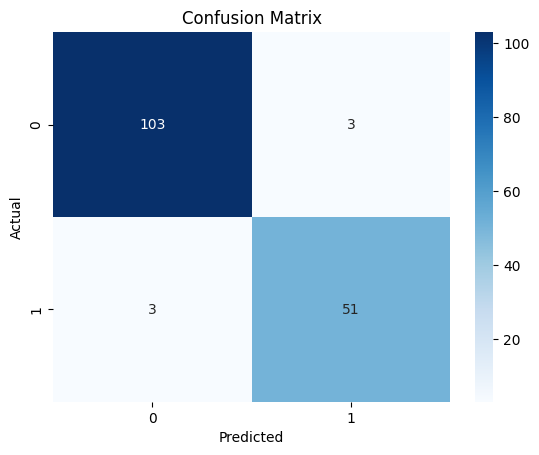

In [6]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()


## Takeaways
- Check `model.feature_importances_` — glucose and bmi usually dominate, matching real medical intuition.
- Try plotting training vs test accuracy across `n_estimators` (staged prediction via `staged_predict`) to see overfitting emerge if boosting runs too long.
- Next steps: compare against XGBoost (next topic) on the same data to see the speed/regularization improvements.

---
# Project 2 — Your Turn
**Dataset:** Tips dataset (`seaborn.load_dataset('tips')`) — predict whether a customer is a `smoker` (yes/no) from total_bill, tip, size, day, time.

```python
import seaborn as sns
tips = sns.load_dataset('tips')
```
**Tasks:** encode categorical columns, train Gradient Boosting, evaluate with accuracy/F1, and check feature importances to see what predicts smoking status.
